##  Bank Marketing

**Abstract:**
The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. The classification goal is to predict if the client will subscribe to a term deposit (variable y).

**Data Set Information:**
The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required, in order to assess if the product (bank term deposit) would be ('yes') or not ('no') subscribed.

###  Attribute Information:

####  Bank client data:

 - Age (numeric)
 - Job : type of job (categorical: 'admin.', 'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired', 'self-employed', 'services', 'student', 'technician', 'unemployed', 'unknown')
 - Marital : marital status (categorical: 'divorced', 'married', 'single', 'unknown' ; note: 'divorced' means divorced or widowed)
 - Education (categorical: 'basic.4y', 'basic.6y', 'basic.9y', 'high.school',  'illiterate', 'professional.course', 'university.degree', 'unknown')
 - Default: has credit in default? (categorical: 'no', 'yes', 'unknown')
 - Housing: has housing loan? (categorical: 'no', 'yes', 'unknown')
 - Loan: has personal loan? (categorical: 'no', 'yes', 'unknown')

    
####  Related with the last contact of the current campaign:

 - Contact: contact communication type (categorical:
   'cellular','telephone')
 - Month: last contact month of year (categorical: 'jan', 'feb', 'mar',
   ..., 'nov', 'dec')
 - Duration: last contact duration, in seconds (numeric). Important
   note: this attribute highly affects the output target (e.g., if
   duration=0 then y='no'). Yet, the duration is not known before a call
   is performed. Also, after the end of the call y is obviously known.
   Thus, this input should only be included for benchmark purposes and
   should be discarded if the intention is to have a realistic
   predictive model.

    
####  Other attributes:

 - Campaign: number of contacts performed during this campaign and for
   this client (numeric, includes last contact)
 - Pdays: number of days that passed by after the client was last
   contacted from a previous campaign (numeric; 999 means client was not
   previously contacted)
 - Previous: number of contacts performed before this campaign and for
   this client (numeric)
 - Poutcome: outcome of the previous marketing campaign (categorical:
   'failure','nonexistent','success')

####  Output variable (desired target):

 - y - has the client subscribed a term deposit? (binary: 'yes', 'no')

     
###  Source:

 - Dataset from : http://archive.ics.uci.edu/ml/datasets/Bank+Marketing#


### Import the necessary libraries

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#to scale the data using z-score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

#algorithms to use
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

#Metrics to evaluate the model
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, accuracy_score

#to ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Read in the data set using the code:
```
#reading the dataset
import pandas as pd
import requests
from io import StringIO  

orig_url="-----" # copy and paste a Goodle drive share link to the data
file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text

csv_raw = StringIO(url)
bank = pd.read_csv(csv_raw, sep=';') # the sep argument indicates how the data values are separated
```

In [42]:
#reading the dataset
import pandas as pd
import requests
from io import StringIO

orig_url="https://drive.google.com/file/d/1IZQz-1sZtD7R2VVe_JuhWRf5vAMa-B2E/view?usp=sharing"
file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text

csv_raw = StringIO(url)
bank = pd.read_csv(csv_raw, sep=';') # the sep argument indicates how the data values are separated

### Examine the first few lines of the data set using the method

```data_frame.head()```

In [43]:
bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Examine the data information using the method
```data_frame.info()```

In [44]:
# take a look at the type, number of columns, entries, null values etc..
bank.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Check for missing values using the method
```data_frame.isnull().any()```

In [45]:
bank.isnull().any() # one way to search for null values

,0
age,False
job,False
marital,False
education,False
default,False
balance,False
housing,False
loan,False
contact,False
day,False


### Separate the numerical and categorical variables
They will be treated differently in preprocessing and in visualization

In [46]:
# separate the numerical columns
# 'age', 'duration','campaign','pdays', 'previous'

num_cols=['age', 'duration','campaign','pdays', 'previous']

In [47]:
# separate the categorical columns
# 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y'

cat_cols=['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

### Examine the first few rows of the numerical data

In [48]:
bank[num_cols]

,age,duration,campaign,pdays,previous
0,58,261,1,-1,0
1,44,151,1,-1,0
2,33,76,1,-1,0
3,47,92,1,-1,0
4,33,198,1,-1,0
...,...,...,...,...,...
45206,51,977,3,-1,0
45207,71,456,2,-1,0
45208,72,1127,5,184,3
45209,57,508,4,-1,0


### Run a statistical summary of the numerical data

In [49]:
bank[num_cols].describe()

,age,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,258.163080,2.763841,40.197828,0.580323
std,10.618762,257.527812,3.098021,100.128746,2.303441
min,18.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,4918.000000,63.000000,871.000000,275.000000


### Examine the first few rows of the categorical data


In [50]:
bank[cat_cols].head()

,job,marital,education,default,housing,loan,contact,month,poutcome,y
0,management,married,tertiary,no,yes,no,unknown,may,unknown,no
1,technician,single,secondary,no,yes,no,unknown,may,unknown,no
2,entrepreneur,married,secondary,no,yes,yes,unknown,may,unknown,no
3,blue-collar,married,unknown,no,yes,no,unknown,may,unknown,no
4,unknown,single,unknown,no,no,no,unknown,may,unknown,no


### Creating dummy variables for the categorical variables.

Before doing so, check for the unique values in the column using the ```unique()``` method. The variables with only two values will be handled differently (note that this separation is not a requirement, merely conventional).

```data_frame['column'].unique()```

In [51]:
bank['job'].unique()

array(['management', 'technician', 'entrepreneur', 'blue-collar',
       'unknown', 'retired', 'admin.', 'services', 'self-employed',
       'unemployed', 'housemaid', 'student'], dtype=object)

In [52]:
bank['marital'].unique()

array(['married', 'single', 'divorced'], dtype=object)

In [53]:
bank['education'].unique()

array(['tertiary', 'secondary', 'unknown', 'primary'], dtype=object)

In [54]:
bank['contact'].unique()

array(['unknown', 'cellular', 'telephone'], dtype=object)

In [55]:
bank['month'].unique()

array(['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb',
       'mar', 'apr', 'sep'], dtype=object)

In [56]:
bank['poutcome'].unique()

array(['unknown', 'failure', 'other', 'success'], dtype=object)

### Get dummies for ```'job', 'marital', 'education', 'contact', 'month', 'poutcome'```
Use the ```get_dummies()``` method for the variables with more than two categories. Reassign the bank data frame so that it has the newly transformed variables.
```
data_frame=pd.get_dummies(data=data_frame, columns=categorical_columns, drop_first=True)
```

In [57]:
#creating list of dummy columns
cat_cols_dummies=['job', 'marital', 'education', 'contact', 'month', 'poutcome']

#creating dummy variables and reassigning the data frame
bank = pd.get_dummies(data = bank, columns= cat_cols_dummies, drop_first= True)


### Convert ```yes', 'no'``` to ```0, 1```
For categorical variables with 'yes' or 'no' values, convert the 'yes' to 1 and the 'no' values to 0.

In [58]:
bank['default'].unique()

array(['no', 'yes'], dtype=object)

In [59]:
bank['housing'].unique()

array(['yes', 'no'], dtype=object)

In [60]:
bank['loan'].unique()

array(['no', 'yes'], dtype=object)

In [61]:
bank['y'].unique()

array(['no', 'yes'], dtype=object)

In [62]:
dict_default={'yes': 1, 'no':0}
dict_housing={'yes': 1, 'no':0}
dict_loan={'yes': 1, 'no':0}
dict_y={'yes': 1, 'no':0}

bank['default']=bank.default.map(dict_default)
bank['housing']=bank.housing.map(dict_housing)
bank['loan']=bank.loan.map(dict_loan)
bank['y']=bank.y.map(dict_y)


### Examine the first few lines of the bank data *set*

In [63]:
bank.head()

,age,default,balance,housing,loan,day,duration,campaign,pdays,previous,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,0,2143,1,0,5,261,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
1,44,0,29,1,0,5,151,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
2,33,0,2,1,1,5,76,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
3,47,0,1506,1,0,5,92,1,-1,0,...,False,False,False,True,False,False,False,False,False,True
4,33,0,1,0,0,5,198,1,-1,0,...,False,False,False,True,False,False,False,False,False,True


Check again for missing values and data types.

In [64]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 43 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   age                  45211 non-null  int64
 1   default              45211 non-null  int64
 2   balance              45211 non-null  int64
 3   housing              45211 non-null  int64
 4   loan                 45211 non-null  int64
 5   day                  45211 non-null  int64
 6   duration             45211 non-null  int64
 7   campaign             45211 non-null  int64
 8   pdays                45211 non-null  int64
 9   previous             45211 non-null  int64
 10  y                    45211 non-null  int64
 11  job_blue-collar      45211 non-null  bool 
 12  job_entrepreneur     45211 non-null  bool 
 13  job_housemaid        45211 non-null  bool 
 14  job_management       45211 non-null  bool 
 15  job_retired          45211 non-null  bool 
 16  job_self-employed    4

Notice that all variables have 45,211 non-null values and that all of the data types are numerical. (watch out for `object` data types)

### Separate the feature variables from the target variable.

In [65]:
#Separating target variable and other variables
y= bank['y']
X= bank.drop(columns = ['y'])

### Scaling the data

The independent variables in this dataset have different scales. When features have differing scales from each other, there is a chance that a higher weightage will be given to features which have a higher magnitude, and they will dominate over other features whose magnitude changes may be smaller but whose percentage changes may be just as significant or even larger. This will impact the performance of our machine learning algorithm, and we do not want our algorithm to be biased towards one feature.

The solution to this issue is **Feature Scaling**, i.e. scaling the dataset so as to give every transformed variable a comparable scale.

In this problem, we will use the **Standard Scaler** method, which centers and scales the dataset using the Z-Score.

It standardizes features by subtracting the mean and scaling it to have unit variance.

The standard score of a sample x is calculated as:

**z = (x - u) / s**

where **u** is the mean of the training samples (zero) and **s** is the standard deviation of the training samples.

### Run the standard scalar to transform the values in the collection of feature values.
```
#Scaling the data
sc=StandardScaler() # imported with the libraries, we give it an alias here

X_scaled=sc.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled, columns=X.columns)
```

In [66]:
#Scaling the data
sc=StandardScaler() # imported with the libraries, we give it an alias here
X_scaled=sc.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled, columns=X.columns)

### Splitting the data into 70% train and 30% test set

Some classification problems can exhibit a large imbalance in the distribution of the target classes: for instance there could be several times more negative samples than positive samples. In such cases it is recommended to use the **stratified sampling** technique to ensure that relative class frequencies are approximately preserved in each train and validation fold.

In [67]:
#splitting the data
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=1,stratify=y)

### Model evaluation criterion

#### The model can make two types of wrong predictions:
1. Predicting an customer will subscribe and the don't
2. Predicting a customer will not subscribe and they do.

Also, let's create a function to calculate and print the classification report and confusion matrix so that we don't have to rewrite the same code repeatedly for each model.

In [68]:
#creating metric function
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Subscribe', 'Subscribe'], yticklabels=['Not Subscribe', 'Subscribe'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

### Logistic Regression Model

- Logistic Regression is a supervised learning algorithm which is used for **binary classification problems** i.e. where the dependent variable is categorical and has only two possible values. In logistic regression, we use the sigmoid function to calculate the probability of an event y, given some features x as:

                                          P(y)=1/exp(1 + exp(-x))

In [69]:
#fitting logistic regression model
lg=LogisticRegression()
lg.fit(X_train,y_train)

LogisticRegression()

### Checking model performance

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     27945
           1       0.66      0.36      0.46      3702

    accuracy                           0.90     31647
   macro avg       0.79      0.67      0.70     31647
weighted avg       0.89      0.90      0.89     31647



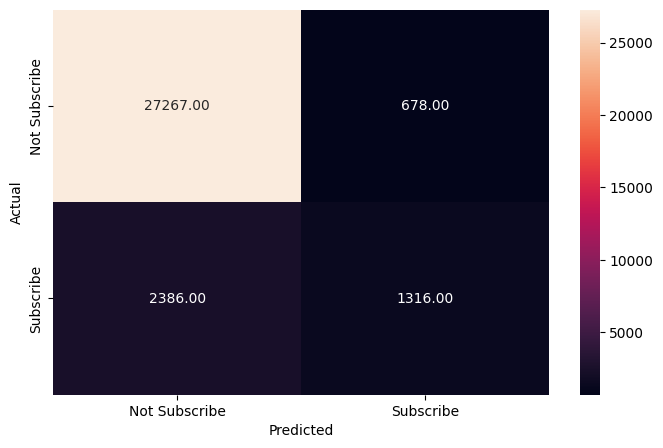

In [70]:
#checking the performance on the training data
y_pred_train_lg = lg.predict(X_train)
metrics_score(y_train, y_pred_train_lg)

              precision    recall  f1-score   support

           0       0.92      0.97      0.95     11977
           1       0.64      0.34      0.44      1587

    accuracy                           0.90     13564
   macro avg       0.78      0.66      0.70     13564
weighted avg       0.88      0.90      0.89     13564



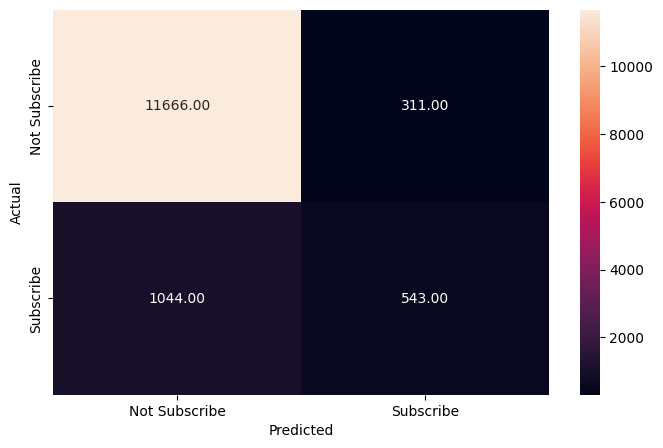

In [71]:
#checking the performance on the test dataset
y_pred_test_lg = lg.predict(X_test)
metrics_score(y_test, y_pred_test_lg)

### Problem 1: Generalization Performance for Logistic Regression
**Compare the training and testing results.**

- **How well does the model perform?**
    - The model's high 90% accuracy is misleading and indicates poor overall performance. This is because the dataset is imbalanced, and the model is very good at predicting the majority class (Not Subscribe). However, it performs very poorly at its actual business goal: identifying potential subscribers (Class 1), for which it only has a recall of 34%.
    
- **Compare the performance on the training and testing data.**
    - The model's performance is extremely stable and consistent across both datasets. The accuracy is 90% on both training and test sets. Furthermore, the key metrics for Class 1 are nearly identical: recall is 36% on train vs. 34% on test, and precision is 66% on train vs. 64% on test.

- **Based on your analysis of the training and testing performance, state whether or not overfitting is a concern and explain how you know.**
    - Overfitting is not a concern. We know this because there is no significant drop in performance between the training data and the unseen test data. The near-identical scores (90% accuracy on both) show that the model generalizes well, even though its overall strategy is not very useful for the business.


- **Interpret the precision and recall values for class 1 in the context of the business scenario.**     
    - *Recall (0.34): This is the most critical failure. It means the bank's model is only finding 34% of all the clients who actually would subscribe to the term deposit. The other 66% of potential customers are being missed entirely.

      Precision (0.64): This means that when the model does flag a client as a "Subscribe," it is correct 64% of the time. While this is decent, it comes at the cost of the very low recall, making it an ineffective tool for finding new leads.*

### Tree Induction Model



In [72]:
#fitting logistic regression model
dt=DecisionTreeClassifier()
dt.fit(X_train,y_train)

DecisionTreeClassifier()

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     27945
           1       1.00      1.00      1.00      3702

    accuracy                           1.00     31647
   macro avg       1.00      1.00      1.00     31647
weighted avg       1.00      1.00      1.00     31647



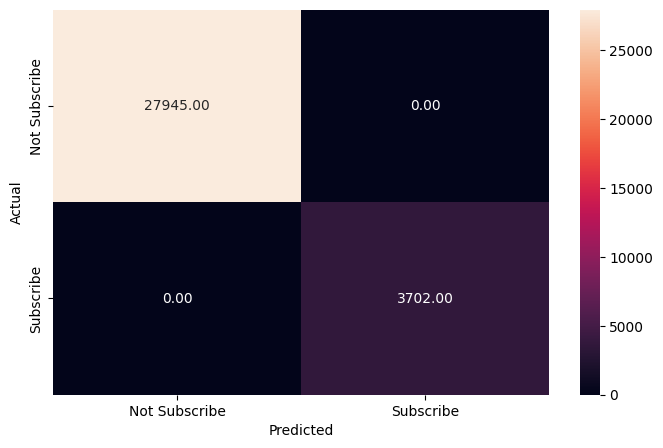

In [73]:
y_pred_train_dt = dt.predict(X_train)
metrics_score(y_train, y_pred_train_dt)

              precision    recall  f1-score   support

           0       0.93      0.93      0.93     11977
           1       0.46      0.47      0.47      1587

    accuracy                           0.87     13564
   macro avg       0.70      0.70      0.70     13564
weighted avg       0.88      0.87      0.87     13564



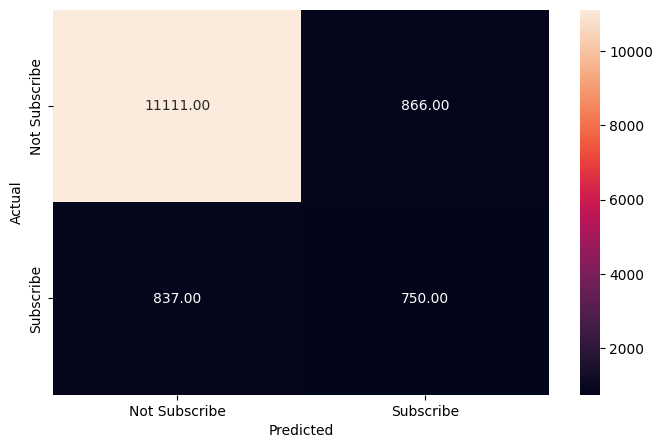

In [74]:
y_pred_test_dt = dt.predict(X_test)
metrics_score(y_test, y_pred_test_dt)

### Problem 2: Generalization Performance for Tree Induction
**Compare the training and testing results.**

- **How well does the model perform?**
    - The model's overall performance is mediocre, with an 88% accuracy on the test set. This is a significant drop from its perfect training performance. More importantly, it struggles with the business objective of finding subscribers (Class 1), achieving only 47% precision and 47% recall for this target group.

- **Compare the performance on the training and testing data.**
    - *There is a massive drop in performance between the two. On the training data, the model achieved perfect 100% accuracy, precision, and recall for both classes, as shown by the perfect confusion matrix. On the testing data, this performance collapsed significantly, with accuracy falling to 88% and the precision and recall for Class 1 (Subscribe) plummeting from 100% to 47%.*

- **Based on your analysis of the training and testing performance, state whether or not overfitting is a concern and explain how you know.**
    - *Yes, overfitting is a major concern and is clearly happening. We know this because the model achieved perfect 100% performance on the training data—a classic sign that it has "memorized" the data, including its noise. This memorization is useless for new data, which is why its performance dropped so dramatically on the unseen test set. This huge gap between training and testing performance is the definition of overfitting.*

- **Interpret the precision and recall values for class 1 in the context of the business scenario.**     
    - Recall (0.47): This means the model is only finding 47% of the clients who actually would subscribe to the term deposit. The bank is therefore missing out on the other 53% of potential customers.

    Precision (0.47): This means that when the model does flag a client as a "Subscribe," it is only correct 47% of the time. The other 53% of the time, the bank would be wasting marketing resources by contacting someone who will not subscribe.

### Tree Model Performance for Varrying Numbers of Nodes

In [75]:
# List of max leaf nodes to try
max_nodes = [2, 3, 4, 5, 10, 20, 50, 100, 200, 500, 1000]
accuracies = []

# Loop over each value of max_leaf_nodes
for nodes in max_nodes:
    # Create and train the Decision Tree model
    model = DecisionTreeClassifier(max_leaf_nodes=nodes, random_state=42)
    model.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Calculate accuracy
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    accuracies.append((accuracy_train, accuracy_test))

accuracy_scores=pd.DataFrame(accuracies, columns=["Training Accuracy", "Testing Accuracy"])
accuracy_scores

,Training Accuracy,Testing Accuracy
0,0.883022,0.882999
1,0.889626,0.888823
2,0.895914,0.894574
3,0.895914,0.894574
4,0.901286,0.899882
5,0.904478,0.901209
6,0.908238,0.903273
7,0.915221,0.902905
8,0.923658,0.899292
9,0.943849,0.895090


### Fitting Curve for Tree Model

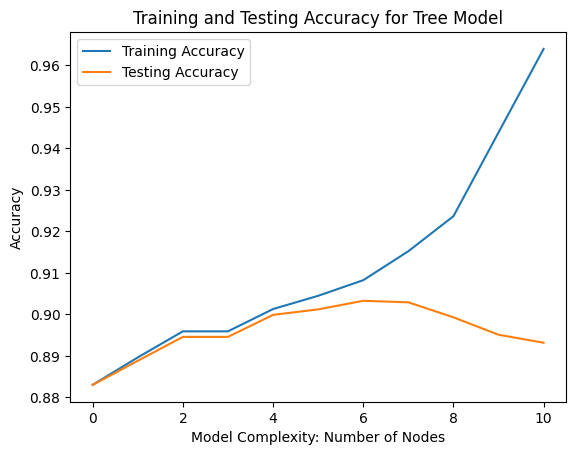

In [76]:
# Import the necessary library for plotting
import matplotlib.pyplot as plt

# Create a figure and axis
fig, ax = plt.subplots()

# Plot both columns on the same axis
ax.plot(accuracy_scores["Training Accuracy"], label="Training Accuracy")
ax.plot(accuracy_scores["Testing Accuracy"], label="Testing Accuracy")

# Add a legend to differentiate the lines
ax.legend()

# Add labels to the axes
ax.set_xlabel("Model Complexity: Number of Nodes")
ax.set_ylabel("Accuracy")

# Add a title to the plot
ax.set_title("Training and Testing Accuracy for Tree Model")

# Display the plot
plt.show()


### Problem 3: Achieving Optimal Performance in Tree Model
**Compare the training and testing results for the tree model.**

- **Based on the fitting graph, how many tree nodes should be used to training the model with the best performance? Explain your reasoning briefly**
    - 6 tree nodes should be used. The reasoning is that the "best performance" is measured by the model's accuracy on new, unseen data, which is represented by the Testing Accuracy (orange) line. This line reaches its highest peak at a model complexity of 6, after which it begins to decrease.


- **Explain how this graph illustrates the balance between fitting and model generalizability.**
    - The graph illustrates the trade-off between fit and generalization: from 0 to 6 nodes, the model is learning, and both training and testing accuracy rise together. At 6 nodes, the model hits its "sweet spot" with the highest testing accuracy, indicating optimal generalization. After 6 nodes, the model begins to overfit; the training accuracy keeps improving, but the testing accuracy drops, showing that the model is just memorizing noise rather than learning useful patterns.


### k-fold Cross Validation for Tree Model

In [77]:
# use k-fold cross validation to examine the performance of the tree model across different folds

import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

# Number of folds for cross-validation
n_splits = 25

# Create a KFold object
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize an empty list to store the accuracy scores for each fold
fold_accuracies = []

# Iterate through the folds
for train_index, test_index in kf.split(X_scaled):
    # Split the data into training and testing sets for the current fold
    X_train_fold, X_test_fold = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Create and train the Decision Tree model
    model = DecisionTreeClassifier(random_state=42)
    model.fit(X_train_fold, y_train_fold)

    # Make predictions on the test set for the current fold
    y_pred_fold = model.predict(X_test_fold)

    # Calculate accuracy for the current fold
    fold_accuracy = accuracy_score(y_test_fold, y_pred_fold)
    fold_accuracies.append(fold_accuracy)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)


### Plot of Model Accuracy for each Fold in the Tree Model

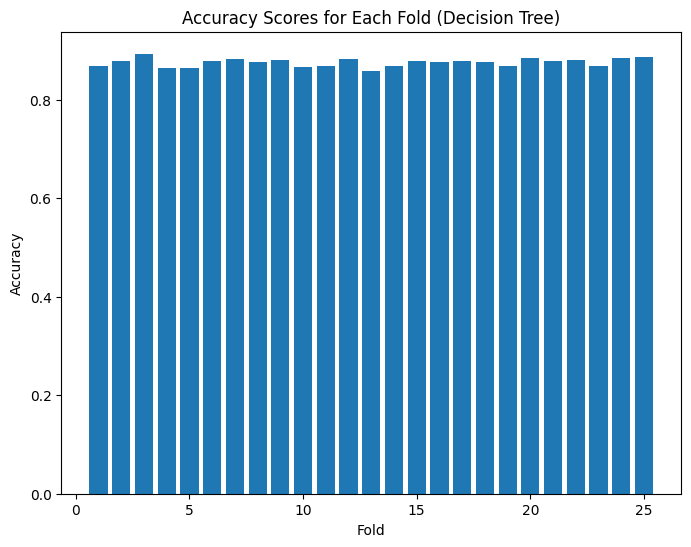

In [78]:
# Create a bar chart to show the accuracies across the different folds?

import matplotlib.pyplot as plt
# Create a bar chart to show the accuracies across the different folds
plt.figure(figsize=(8, 6))
plt.bar(range(1, n_splits + 1), fold_accuracies)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Accuracy Scores for Each Fold (Decision Tree)")
plt.show()


### k-fold Cross Validation for Logistic Regression

In [79]:
import matplotlib.pyplot as plt
import numpy as np
# Number of folds for cross-validation
n_splits = 25

# Create a KFold object
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Initialize an empty list to store the accuracy scores for each fold
fold_accuracies = []

# Iterate through the folds
for train_index, test_index in kf.split(X_scaled):
    # Split the data into training and testing sets for the current fold
    X_train_fold, X_test_fold = X_scaled.iloc[train_index], X_scaled.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    # Create and train the Logistic Regression model
    model = LogisticRegression(random_state=42)
    model.fit(X_train_fold, y_train_fold)

    # Make predictions on the test set for the current fold
    y_pred_fold = model.predict(X_test_fold)

    # Calculate accuracy for the current fold
    fold_accuracy = accuracy_score(y_test_fold, y_pred_fold)
    fold_accuracies.append(fold_accuracy)

# Calculate the average accuracy across all folds
average_accuracy = np.mean(fold_accuracies)

### Plot of Model Accuracy for each Fold in the Logistic Regression Model

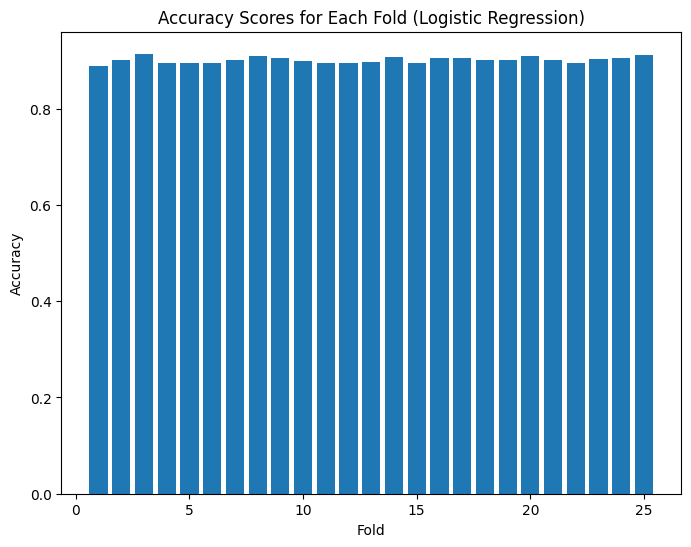

In [80]:
# Create a bar chart to show the accuracies across the different folds
plt.figure(figsize=(8, 6))
plt.bar(range(1, n_splits + 1), fold_accuracies)
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("Accuracy Scores for Each Fold (Logistic Regression)")
plt.show()

### Problem 4: k-fold Cross Validation

- **Examine the code and determine the value of k in the k-fold Cross Validation procedure**
    - The value of K is 25

- **Describe the purpose of k-fold Cross Validation**
    - The purpose of k-fold cross-validation is to get a more reliable and stable estimate of a model's performance on unseen data. It works by splitting the dataset into k equal-sized folds, then training and testing the model k times. In each iteration, one fold is held out as the test set, and the remaining k-1 folds are used for training. The final performance is typically the average of all k test scores.

- **Explain why k-fold Cross Validation can provide more information than simply using a single train-test-split.**
    - A single train-test-split provides only one performance score (e.g., one accuracy number). This single score can be misleading if the split is lucky or unlucky.K-fold cross-validation provides k different scores, one for each fold. This gives you a much richer picture, including an average score (which is more reliable) and the variance or spread of the scores (which tells you how stable the model's performance is).

- **In what scenarios would using k-fold Cross Validation be advantageous.**
    - K-fold is almost always advantageous, but it's especially critical in two scenarios. First, when working with smaller datasets, because it allows us to use more of your limited data for training in each run. Second, it is the standard for hyperparameter tuning and model selection (e.g., choosing between the Logistic Regression and Decision Tree models), as it provides a robust average score to make a fair comparison.

### Creating a Learning Curve for the Tree and the Logistic Regression Models

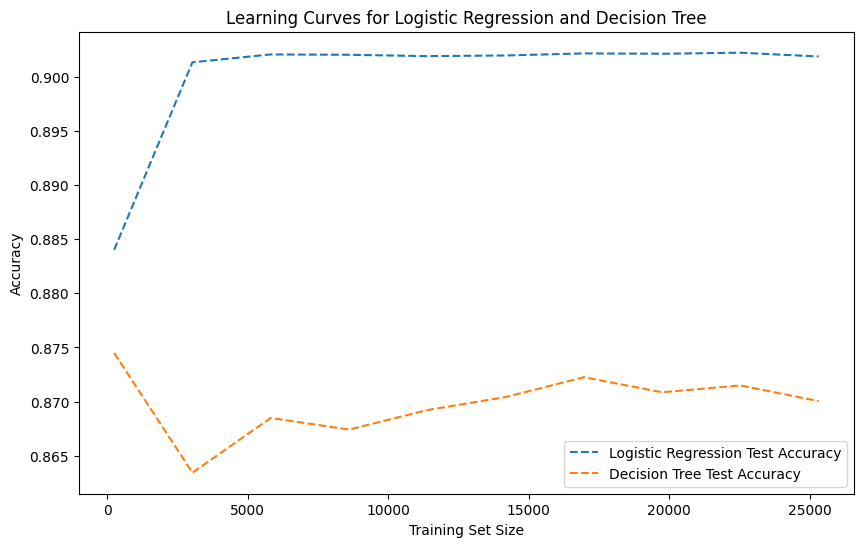

In [81]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import learning_curve

# Generate learning curves for Logistic Regression
train_sizes_abs, train_scores_lg, test_scores_lg = learning_curve(
    LogisticRegression(), X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 10), scoring='accuracy'
)

# Generate learning curves for Decision Tree
train_sizes_abs, train_scores_dt, test_scores_dt = learning_curve(
    DecisionTreeClassifier(), X_train, y_train, train_sizes=np.linspace(0.01, 1.0, 10), scoring='accuracy'
)

# Calculate mean and standard deviation of training/test scores
test_mean_lg = np.mean(test_scores_lg, axis=1)
test_mean_dt = np.mean(test_scores_dt, axis=1)

# Plot the results
plt.figure(figsize=(10, 6))

# Plot for Logistic Regression
plt.plot(train_sizes_abs, test_mean_lg, label="Logistic Regression Test Accuracy", linestyle='--')

# Plot for Decision Tree
plt.plot(train_sizes_abs, test_mean_dt, label="Decision Tree Test Accuracy", linestyle='--')

plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curves for Logistic Regression and Decision Tree")
plt.legend()
plt.show()


### Problem 5: Comparing Model Performance by Training Set Size
**Compare the performance of the models developed through logistic regression and tree induction.**

- **Which model is superior overall and why?**
    - The Logistic Regression model is superior overall. At every training set size shown, its test accuracy is consistently and significantly higher than the Decision Tree's test accuracy.

- **Describe the performance of the Logistic Regression model as a function of training set size.**
    - The Logistic Regression model's performance improves sharply with the first few thousand data points. After this initial gain, its performance plateaus and remains very high and stable, indicating that it learned its patterns quickly and does not benefit significantly from more data after
    5,000 samples.

- **Describe the performance of the Decision Tree model as a function of training set size.**
    - The Decision Tree model's performance is lower and much more erratic. It starts relatively high, sees an initial drop in accuracy, and then slowly trends upward with significant fluctuations. It never achieves the high, stable accuracy of the logistic regression model, suggesting it is less stable and less effective on this dataset.



### Problem 6: Overall Recommendations
**Which of the two models examinined in this analysis do you recommend the company use for their targeted marketing campaign. Please discuss some of the model evaluation techniques used to check model performance and how the results informed your choice of model.**

I recommend the Logistic Regression model because it is stable, accurate, and does not overfit. However, before deployment, it must be re-tuned to address the low recall. The bank's goal is to find subscribers, so the model should be optimized (e.g., by using class weights or adjusting the decision threshold) to increase its recall for Class 1, even if it means sacrificing some precision.

While the decision tree's 47% test recall is currently higher, that model is severely overfit (100% train accuracy vs. 88% test), making its performance metrics unreliable and untrustworthy. The logistic regression model is stable (90% train vs. 90% test), so its 34% recall is an honest, reliable baseline. Therefore, the logistic regression is the superior choice because it's a stable